In [1]:
from pyrootmemo import Parameter
from pyrootmemo.materials import MultipleRoots, Interface
from pyrootmemo.models import AxialPullout

ImportError: cannot import name 'AxialPullout' from 'pyrootmemo.models.axial_pullout' (C:\Users\gjm36\Documents\github\pyrootmemo\src\pyrootmemo\models\axial_pullout.py)

# Axial pullout

Predict pull-out forces for bundles of roots. This class follows models 
developed by Waldron (1977), Waldron & Dakessian (1981) and the DRAM model
developed by Meijer et al. (2022), in the sense that displacements and 
forces are mobilised due to the interaction between root-soil interface 
resistance and root stiffness.

This model class can take a wide variety of different root behaviours, 
and therefore incorporates the models by a wide variety of authors. for 
example, this class can take into account:

* root breakage
* root slippage
* elastic or elasto-plastic root behaviour
* 'embedded' behaviour (e.g. roots always remain fully surrounded by soil) or 
    'surface' behaviour, in which the root length in contact with the soil
    gradually reduces as more and more root length will gradually emerge above
    the soil surface
* root survival functions, which determined whether roots break 'suddenly'
    or gradually as an 'average' root, as govered by the weibull shape 
    parameter. This is implemented by looking at the ratio between the force
    at failure and the currently mobilised force in a root, assuming no 
    breakage.

These models underpin models for roots loaded in direct shear, such as `Waldron`
or `Dram`.


## Create a model object

Define some roots, using the `MultipleRoots` class. The AxialPullout model 
requires the following root attributes to be defined:

* Root diameter: (`diameter`)
* Root tensile strength (`tensile strength`)
* Root elastic stiffness (`elastic_modulus`)
* Root length (`length`)

In addition, in the case of elasto-plastic behaviour it also requires:

* Root yield strength (`yield_strength`)
* Root plastic stiffness (`plastic_modulus`)

In the case of modelling roots being pulled out of a soil surface, the length
of root initially sticking out of the soil surface must be defined:

* Initial root length above surface (`length_surface`)

In [ ]:
roots = MultipleRoots(
    species = 'test_species',
    diameter = Parameter([1, 2, 3, 4], 'mm'),
    tensile_strength = Parameter([50, 30, 10, 5], 'MPa'),
    elastic_modulus = Parameter([200, 200, 200, 200], 'MPa'),
    length = Parameter([1, 1, 1, 1], 'm'),
    yield_strength = Parameter([20, 15, 5, 2.5], 'MPa'),
    plastic_modulus = Parameter([50, 50, 50, 50], 'MPa'),
    length_surface = Parameter([0, 0, 0, 0], 'm')
    )

We also need to define the root-soil interface behaviour, using the `Interface` class:

In [ ]:
interface = Interface(
    shear_strength = Parameter(10, 'kPa')
    )

Next, create an instance of the Axial pullout class. The following example will model:

* Roots being pulled out of the soil surface (`surface = True`)
* Roots tensile failure is allowed (`breakage = True`)
* Root slipping is allowed (`slipping = True`)
* Elasto-plastic root behaviour is enabled (`elastoplastic = True`)

Weibull failure distributions, such as in the RBMw, can be implemented by
specifying the `weibull_shape` input argument. If not defined, roots are assumed
to break suddenly.

In [ ]:
pullout = AxialPullout(
    roots, 
    interface,
    surface = True,
    breakage = True, #True,
    slipping = True,
    elastoplastic = True,
    weibull_shape = 50.0
    )

## Calculations

Various calculations can be made. The method calculated results are returned
depends on the "results" input argument that can be defined for each calculation
function:

* `results = "attribute"` (default behaviour): calculated model results are 
stored in a dictionary in the `output` attribute of the class.
* `results = "return"`: functions returns a dictionary with results, without 
writing to class' `output` attribute
* `results = "both"`: functions both returns dictionary output *and* writes 
to the `output` attribute.
 
### Force (`calc_force()`)

To calculate the current tensile force in each root at a specific level of 
pullout displacement, first do the calculation and then request the results 
from the `output` attribute:

In [ ]:
displacement = Parameter(2, 'mm')
pullout.calc_force(displacement)
print(pullout.output['force_per_root'])

[4.382176860925242 12.443751463196918 22.901151374098504 34.753251217743454] newton


Also calculated are:

* The fraction of roots still intact (`survival_fraction`)
* The current behaviour of the root (`behaviour_index`). The name of the 
  behaviours is stored in the `behaviour_types` key of the `output` dictionary

In [ ]:
print(pullout.output['survival_fraction'])
print(pullout.output['behaviour_types'][pullout.output['behaviour_index']])

[1. 1. 1. 1.]
['Anchored, elastic' 'Anchored, elastic' 'Anchored, elastic'
 'Anchored, plastic']


In this case, because the displacement is very small, roots are mostly still instact and the behaviour is still elastic and anchored (i.e. no slippage).

This may change when the pullout displacement is much larger, e.g.:

In [ ]:
displacement = Parameter(100.0, 'mm')
pullout.calc_force(displacement)
print(pullout.output['force_per_root'])
print(pullout.output['survival_fraction'])
print(pullout.output['behaviour_types'][pullout.output['behaviour_index']])

[23.734866604301477 57.362316333381884 0.0 0.0] newton
[1. 1. 0. 0.]
['Anchored, plastic' 'Slipping, plastic' 'Slipping, plastic'
 'Slipping, plastic']


The `calc_force()` function is vectorised. If displacements are defined as a 
one-dimensional array, the response of every root is calculated at each 
displacement. Results are returned as two-dimensional arrays, with the first
axis representing displacements and the second the response of individual roots.

Text(0, 0.5, 'Tensile stress [newton / millimeter ** 2]')

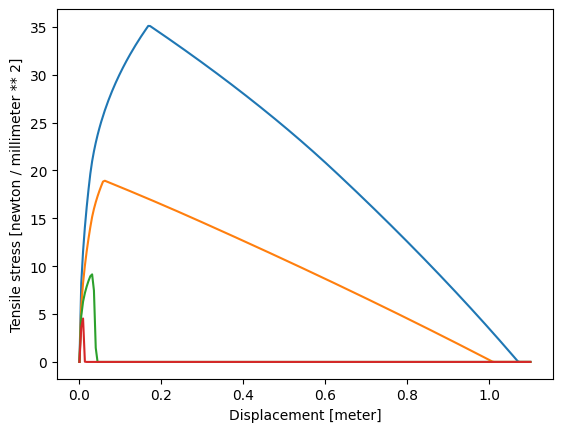

In [ ]:
import numpy as np
displacement = Parameter(np.linspace(0, 1.1, 250), 'm')
pullout.calc_force(displacement)
stress_per_root = pullout.output['force_per_root'] / roots.xsection
displacement_per_root = pullout.output['displacement_per_root']

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for u, t in zip(displacement_per_root.T, stress_per_root.T):
    ax.plot(u.magnitude, t.magnitude)
ax.set_xlabel('Displacement [' + str(displacement_per_root.units) + ']')
ax.set_ylabel('Tensile stress [' + str(stress_per_root.units) + ']')


Alternatively, displacements can be speficied as a two-dimensional array, in 
which the displacement is individually specified for each root (second axis; 
columns) for every moment in 'time' (first axis; rows). This can be useful when
root all roots get pulled at the same rate, e.g. because of differences in 
orientation.

In [ ]:
displacement = Parameter(np.random.rand(4, len(roots.xsection)), 'mm')
pullout.calc_force(displacement)
print(pullout.output['displacement_per_root'])
print(pullout.output['force_per_root'])

[[0.3136834367114898 0.4415475375349839 0.10300211870976883  0.643336330137804] [0.10293029399166953 0.7611523780675354 0.5377069038915868  0.36098994088690095] [0.7543447175534777 0.06667689729362836 0.39131241963606445  0.5410189282224773] [0.6279254496400322 0.6884425513914216 0.4426354019178934  0.12457941664454941]] millimeter
[[1.7498068135402747 5.877084249631565 5.229414615591338  20.078488075591736] [1.0047013846073298 7.705200506621026 11.920138478583112  15.055337895544994] [2.7053703767675543 2.290300497134268 10.17504360309124  18.418765072676706] [2.4701072113381954 7.330103284178733 10.819303577693972  8.85521803093252]] newton
